## Using SAM and LBMS to refine the SAM model using EMPS images maybe!?

In [1]:
import sys
sys.path.append('/Users/tjsss/Desktop/bharatAtomic/semPhase2')


In [2]:
import torch
import torch.distributed
import torch.nn.functional as F
from torch.nn.init import trunc_normal_

import logging

from typing import List, Optional, Tuple, Union

import numpy as np
import torch
from PIL import Image
import importlib
import matplotlib.pyplot as plt

sys.path.insert(0, "/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/LBMS_SAM/SAM")

from SAM.modeling.sam.mask_decoder import MaskDecoder
from SAM.modeling.sam.prompt_encoder import PromptEncoder
from SAM.modeling.sam.transformer import TwoWayTransformer
from SAM.modeling.sam2_utils import get_1d_sine_pe, MLP, select_closest_cond_frames

from SAM.modeling.sam.transformer import RoPEAttention
from SAM.modeling.sam2_utils import get_activation_fn, get_clones



from SAM.modeling.sam2_base import SAM2Base
from SAM.utils.transforms import SAM2Transforms
from SAM.sam2_image_predictor import SAM2ImagePredictor


from SAM.build_sam import build_sam2
from SAM.sam2_image_predictor import SAM2ImagePredictor

import lbms_sam_integration
from lbms_sam_integration import LBMSSAM2Integration

In [3]:
importlib.reload(lbms_sam_integration)
from lbms_sam_integration import LBMSSAM2Integration

In [4]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"


device = torch.device("cpu")
print(f"using device: {device}")

using device: cpu


In [5]:
from hydra import initialize, compose, initialize_config_dir
config_dir = '/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/LBMS_SAM/SAM/configs/sam2.1/'
model_cfg = "sam2.1_hiera_b+.yaml"
sam2_checkpoint = "/Users/tjsss/Desktop/bharatAtomic/semPhase2/main_folder/models/LBMS_SAM/SAM/weights/sam2.1_hiera_base_plus copy.pt"


In [6]:
with initialize_config_dir(config_dir = config_dir , version_base = '1.2'):
    sam2_model = build_sam2(model_cfg, sam2_checkpoint, device=device)
    predictor = SAM2ImagePredictor(sam2_model)
    lbms_sam = LBMSSAM2Integration(sam2_model)

<function matplotlib.pyplot.show(close=None, block=None)>

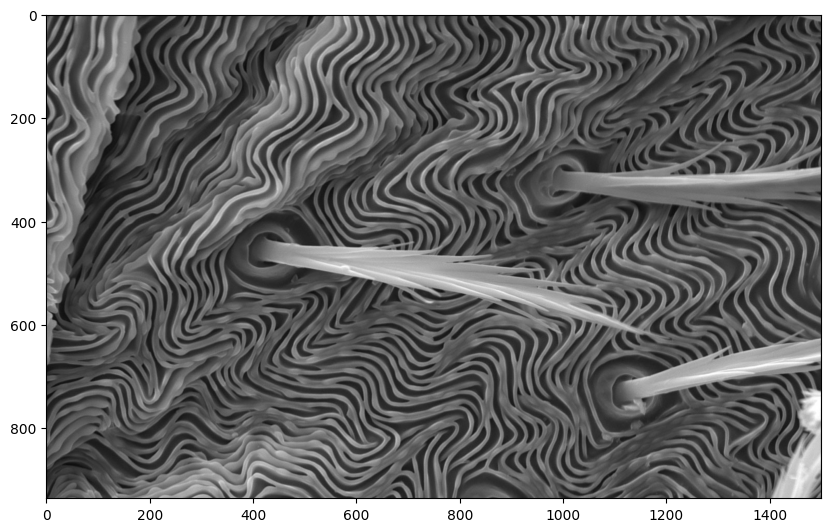

In [7]:
img = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/Red-Velvet-Mite-SEM-Image.jpg'
image = Image.open(img)

width, height = image.size
pixels_to_remove = 60
new_height = height - pixels_to_remove
cropped_img = image.crop((0, 0, width, new_height))




image = np.array(cropped_img.convert('RGB'))

plt.figure(figsize=(10,10))
plt.imshow(image)
plt.axis('on')
plt.show

In [8]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=2) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) > 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [9]:
predictor.set_image(image)
lbms_sam.set_image(image)

In [10]:
input_point = np.array([[300, 650]])
input_label = np.array([1])

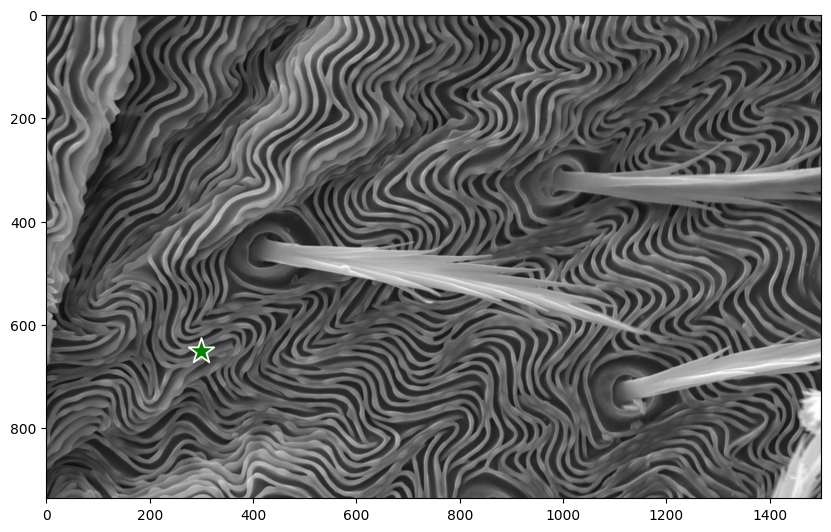

In [11]:
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_points(input_point, input_label, plt.gca())
plt.axis('on')
plt.show()  

In [12]:
print(predictor._features["image_embed"].shape, predictor._features["image_embed"][-1].shape)

torch.Size([1, 256, 64, 64]) torch.Size([256, 64, 64])


In [13]:
masks, scores, logits, mask_feat, mask_channels, output_tokens = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)
sorted_ind = np.argsort(scores)[::-1]
masks = masks[sorted_ind]
scores = scores[sorted_ind]
logits = logits[sorted_ind]



In [21]:
image_tensor = ((torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).float().to(device)) / 255.0)

sam_masks, sam_scores, sam_logits, sam_mask_feats,mask_channels, lbms_sam_masks, lbsm_scores = lbms_sam.forward(
    prompts = {
        "point_coords": input_point,
        "point_labels": input_label,
        "multimask_output": True
    })


Mask_Channels from SAM2.predict function:  32
Mask Features from SAM2.predict function:  torch.Size([1, 32, 256, 256])


In [23]:
sam_masks.shape

(3, 936, 1500)

In [20]:
lbms_sam_masks.shape

(256, 256)

ValueError: not enough values to unpack (expected 2, got 1)

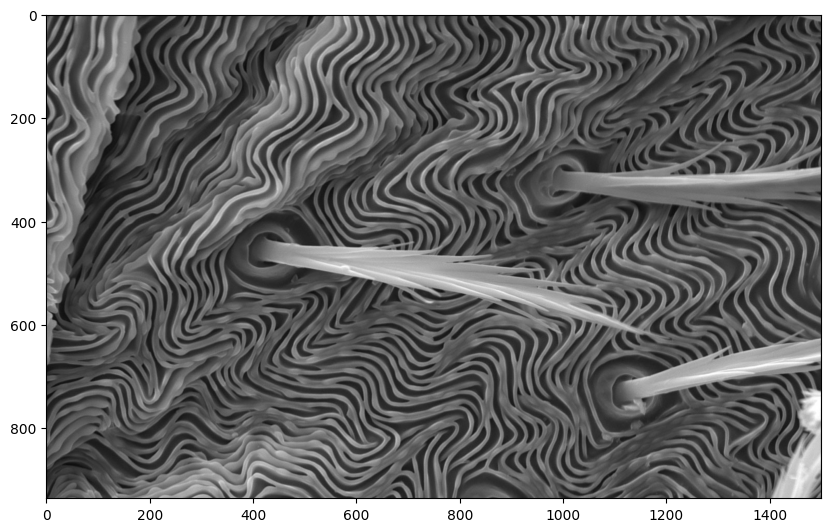

In [17]:
show_masks(image, lbms_sam_masks, lbms_sam_scores, point_coords=input_point, input_labels=input_label, borders=False)

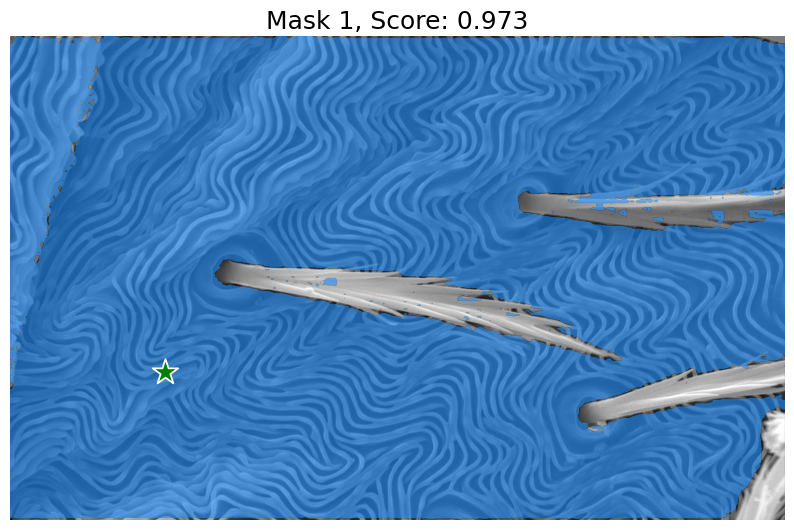

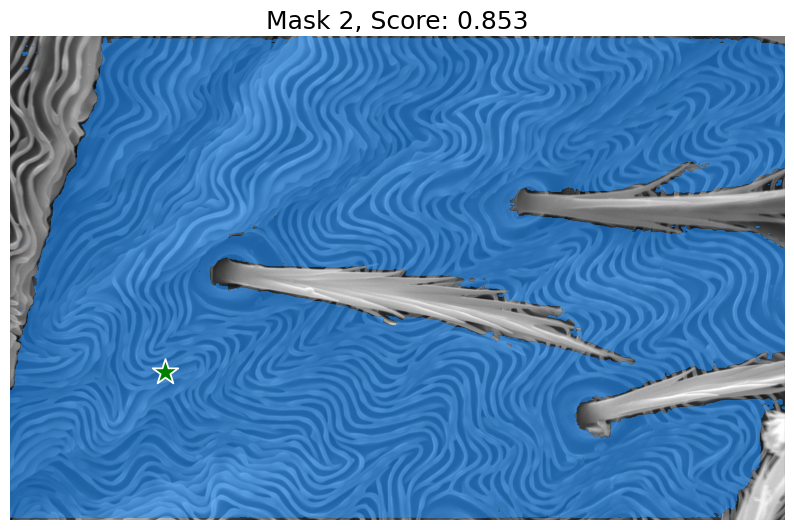

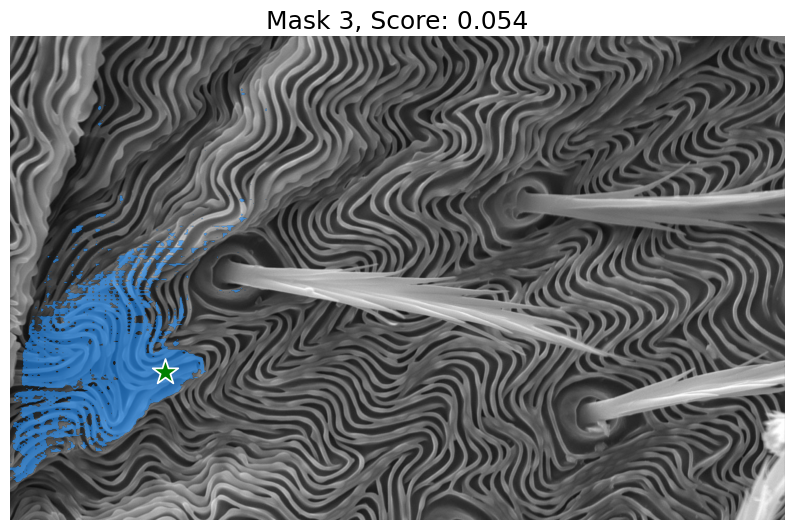

In [36]:
show_masks(image, masks, scores, point_coords=input_point, input_labels=input_label, borders=False)